# FlightPath to Loyalty: Predictive Modeling and Driver Analysis of Airline Passenger Satisfaction
**Author:** Piyush  
**Role:** Principal Data Analyst & Machine Learning Engineer  
**Dataset:** Airline Passenger Satisfaction Survey (129,880 observations, 24 attributes)  

---

## Executive Summary
In the competitive aviation industry, passenger satisfaction directly dictates brand equity, repeat bookings, and customer lifetime value (LTV). This project presents an end-to-end data analytics and machine learning solution that investigates the multidimensional drivers of passenger sentiment and delivers a production-grade predictive classification engine.

### Project Objectives:
1. **Comprehensive Data Quality Audit & Cleaning**: Address missingness, calibrate Likert-scale non-responses ("0 = Not Applicable"), and engineer robust modeling pipelines without data leakage.
2. **Exploratory Data Analysis (EDA)**: Uncover empirical relationships between passenger demographics, travel classes, journey touchpoints, operational delays, and satisfaction outcomes.
3. **Supervised Machine Learning**: Train, tune, and evaluate classification models (Logistic Regression vs. Random Forest) using an 80/20 stratified split.
4. **Driver Decomposition & Prescriptive Analytics**: Quantify feature importance to establish actionable, high-ROI intervention strategies for airline leadership.


## 1. Environment Setup & Library Imports
We initialize standard numerical, analytical, machine learning, and visualization libraries. All random seeds are fixed for strict reproducibility.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)

# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Data Loading & Quality Audit
We ingest `airline_passenger_satisfaction.csv` and cross-reference with `data_dictionary.csv`. We audit dimensions, data types, missing records, duplicates, and statistical ranges.


In [2]:
# Load dataset
df_raw = pd.read_csv("airline_passenger_satisfaction.csv")

print(f"Dataset Shape: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns")
print(f"Exact Duplicate Rows: {df_raw.duplicated().sum()}")
print(f"Unique Passenger IDs: {df_raw['ID'].nunique():,} (Matches row count)")
print("\nColumn Data Types:")
print(df_raw.dtypes)


Dataset Shape: 129,880 rows, 24 columns
Exact Duplicate Rows: 0
Unique Passenger IDs: 129,880 (Matches row count)

Column Data Types:
ID                                          int64
Gender                                     object
Age                                         int64
Customer Type                              object
Type of Travel                             object
Class                                      object
Flight Distance                             int64
Departure Delay                             int64
Arrival Delay                             float64
Departure and Arrival Time Convenience      int64
Ease of Online Booking                      int64
Check-in Service                            int64
Online Boarding                             int64
Gate Location                               int64
On-board Service                            int64
Seat Comfort                                int64
Leg Room Service                            int64
Cleanliness     

In [3]:
# Missing values audit
null_counts = df_raw.isnull().sum()
null_pct = (null_counts / len(df_raw)) * 100
missing_df = pd.DataFrame({'Missing_Count': null_counts, 'Percentage': null_pct})
print(missing_df[missing_df['Missing_Count'] > 0])


               Missing_Count  Percentage
Arrival Delay            393    0.302587


In [4]:
# Survey Rating 0-values (Not Applicable) audit
rating_cols = [
    'Departure and Arrival Time Convenience', 'Ease of Online Booking',
    'Check-in Service', 'Online Boarding', 'Gate Location', 'On-board Service',
    'Seat Comfort', 'Leg Room Service', 'Cleanliness', 'Food and Drink',
    'In-flight Service', 'In-flight Wifi Service', 'In-flight Entertainment',
    'Baggage Handling'
]

zero_summary = []
for col in rating_cols:
    z_count = (df_raw[col] == 0).sum()
    zero_summary.append({'Feature': col, 'Zero_Count': z_count, 'Zero_Pct': round(z_count/len(df_raw)*100, 2)})

print(pd.DataFrame(zero_summary).to_string(index=False))


                               Feature  Zero_Count  Zero_Pct
Departure and Arrival Time Convenience        6681      5.14
                Ease of Online Booking        5682      4.37
                      Check-in Service           1      0.00
                       Online Boarding        3080      2.37
                         Gate Location           1      0.00
                      On-board Service           5      0.00
                          Seat Comfort           1      0.00
                      Leg Room Service         598      0.46
                           Cleanliness          14      0.01
                        Food and Drink         132      0.10
                     In-flight Service           5      0.00
                In-flight Wifi Service        3916      3.02
               In-flight Entertainment          18      0.01
                      Baggage Handling           0      0.00


## 3. Data Preprocessing & Pipeline Construction

### Cleaning & Transformation Strategy:
1. **Target Encoding**: `Satisfaction` is mapped to binary integer format (`1` for `Satisfied`, `0` for `Neutral or Dissatisfied`).
2. **Identifier Exclusion**: `ID` is excluded from all predictor matrices to prevent artificial memorization.
3. **Arrival Delay Imputation**: Missing values (393 rows, 0.30%) are imputed using median values computed strictly from training data folds.
4. **Categorical Encoding**: `Gender`, `Customer Type`, `Type of Travel`, and `Class` are encoded using `OneHotEncoder(drop='first', handle_unknown='ignore')`.
5. **Continuous Scaling**: Numerical features are scaled with `StandardScaler` within the pipeline.


In [5]:
# Separate target and features
target_col = "Satisfaction"
y = df_raw[target_col].apply(lambda x: 1 if x == "Satisfied" else 0)
X = df_raw.drop(columns=["ID", target_col])

# Partition dataset: 80% Train, 20% Test (Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training observations: {X_train.shape[0]:,} ({X_train.shape[0]/len(df_raw):.1%})")
print(f"Testing observations:  {X_test.shape[0]:,} ({X_test.shape[0]/len(df_raw):.1%})")
print(f"Target balance in Train: Satisfied = {y_train.mean():.2%}, Dissatisfied = {1-y_train.mean():.2%}")
print(f"Target balance in Test:  Satisfied = {y_test.mean():.2%}, Dissatisfied = {1-y_test.mean():.2%}")


Training observations: 103,904 (80.0%)
Testing observations:  25,976 (20.0%)
Target balance in Train: Satisfied = 43.45%, Dissatisfied = 56.55%
Target balance in Test:  Satisfied = 43.45%, Dissatisfied = 56.55%


In [6]:
# Construct Scikit-Learn ColumnTransformer Preprocessing Pipeline
categorical_cols = ["Gender", "Customer Type", "Type of Travel", "Class"]
continuous_cols = ["Age", "Flight Distance", "Departure Delay", "Arrival Delay"]

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, continuous_cols + rating_cols),
        ('cat', cat_pipeline, categorical_cols)
    ],
    remainder='drop'
)

print("Preprocessing pipeline built successfully.")


Preprocessing pipeline built successfully.


## 4. Exploratory Data Analysis & Empirical Insights
We generate empirical visualizations using the actual dataset to analyze passenger behavior across key dimensions.

*Note: All analyses demonstrate empirical association and correlation; we refrain from making unsupported causal claims.*


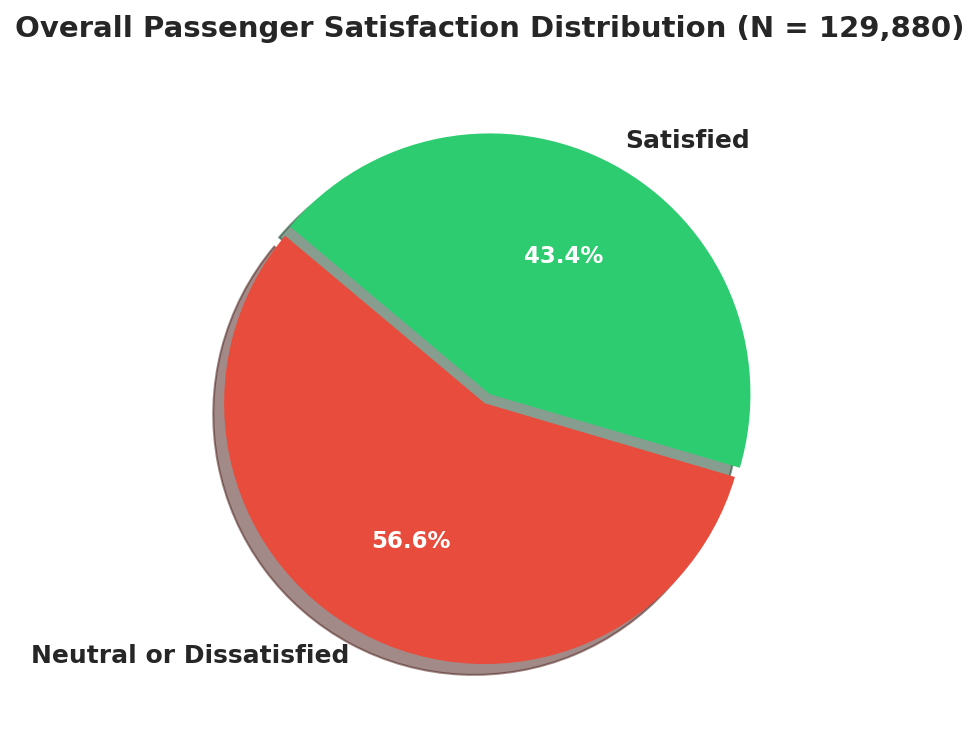

In [7]:
# Visualization 1: Overall Passenger Satisfaction Distribution
fig, ax = plt.subplots(figsize=(7, 5))
counts = df_raw['Satisfaction'].value_counts()
colors = ['#e74c3c', '#2ecc71']
ax.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=(0.04, 0),
    shadow=True,
    textprops={'fontsize': 12, 'weight': 'bold'}
)
ax.set_title("Overall Passenger Satisfaction Distribution (N = 129,880)", fontsize=14, weight='bold', pad=15)
plt.show()


**Empirical Interpretation (Visualization 1):**  
Across the complete sample of 129,880 passengers:
- **Neutral or Dissatisfied:** **56.55% (73,452 passengers)**
- **Satisfied:** **43.45% (56,428 passengers)**  
This underscores that more than half of the passenger base experiences service friction, highlighting substantial retention risk.


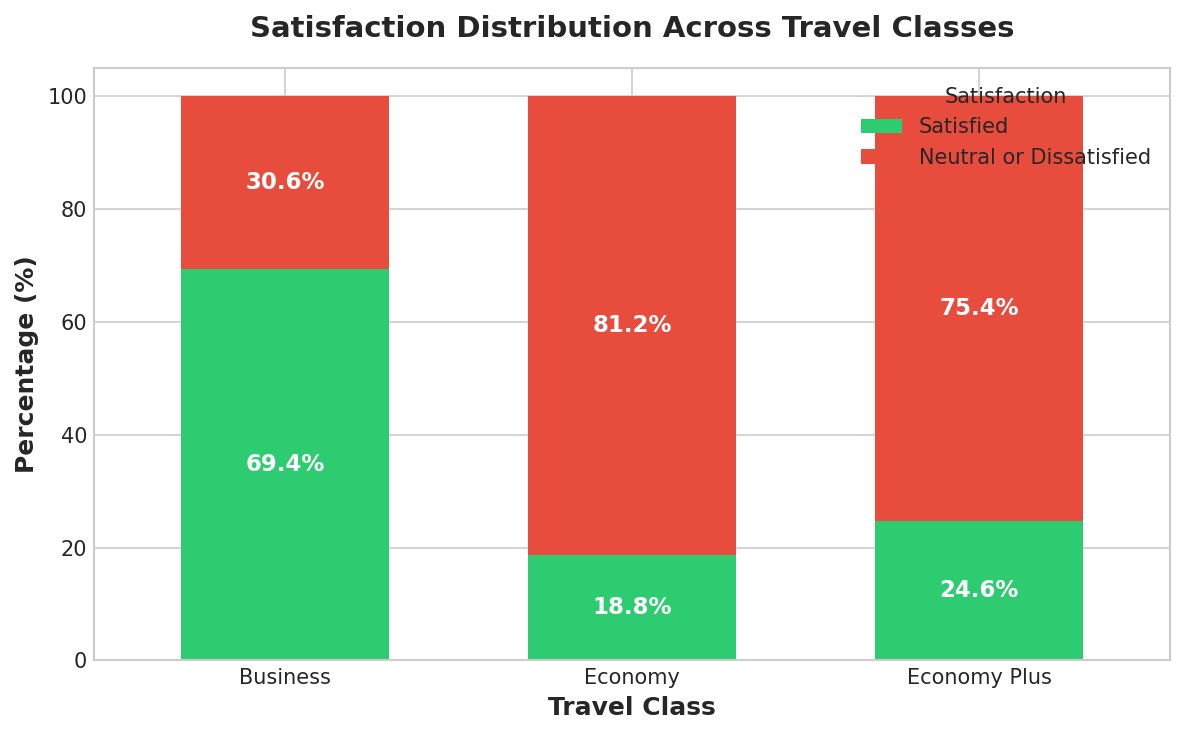

In [8]:
# Visualization 2: Satisfaction Distribution Across Cabin Classes
fig, ax = plt.subplots(figsize=(8, 5))
class_sat = pd.crosstab(df_raw['Class'], df_raw['Satisfaction'], normalize='index') * 100
class_sat = class_sat[['Satisfied', 'Neutral or Dissatisfied']]
class_sat.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], ax=ax, width=0.6)
ax.set_title("Satisfaction Distribution Across Travel Classes", fontsize=14, weight='bold', pad=15)
ax.set_xlabel("Travel Class", fontsize=12, weight='bold')
ax.set_ylabel("Percentage (%)", fontsize=12, weight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 5:
        x, y = p.get_xy() 
        ax.text(x + width/2, y + height/2, f"{height:.1f}%", ha='center', va='center', color='white', weight='bold', fontsize=11)
ax.legend(title="Satisfaction", loc='upper right')
plt.show()


**Empirical Interpretation (Visualization 2):**  
Cabin class demonstrates a stark association with passenger sentiment:
- **Business Class:** **69.44% Satisfied** vs. **30.56% Dissatisfied**
- **Economy Class:** **18.77% Satisfied** vs. **81.23% Dissatisfied**
- **Economy Plus:** **24.64% Satisfied** vs. **75.36% Dissatisfied**  
Over 81% of standard Economy travelers report being neutral or dissatisfied, representing the airline's largest volume churn vulnerability.


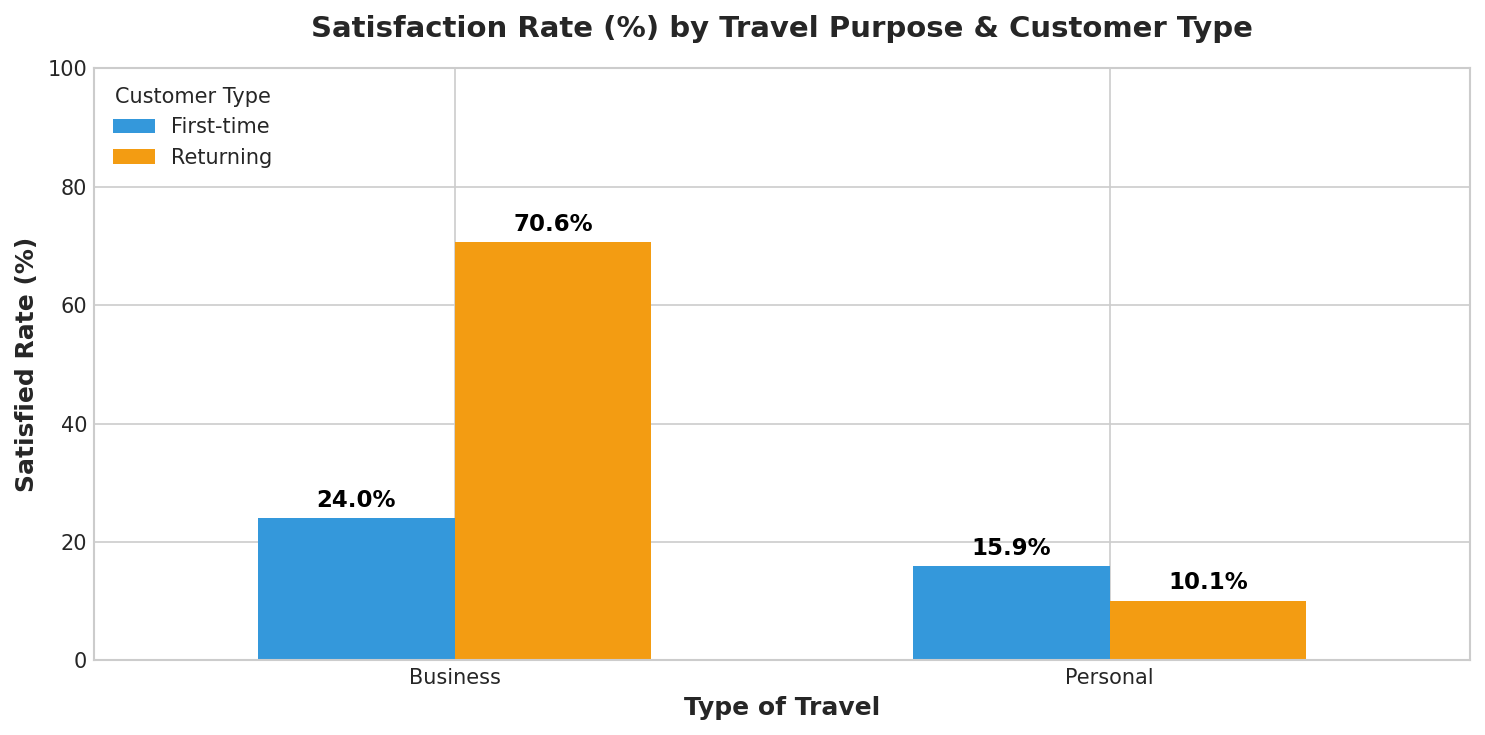

In [9]:
# Visualization 3: Satisfaction by Purpose of Travel & Customer Type
fig, ax = plt.subplots(figsize=(10, 5))
travel_cust = df_raw.groupby(['Type of Travel', 'Customer Type'])['Satisfaction'].apply(lambda s: (s == 'Satisfied').mean() * 100).unstack()

travel_cust.plot(kind='bar', ax=ax, color=['#3498db', '#f39c12'], width=0.6)
ax.set_title("Satisfaction Rate (%) by Travel Purpose & Customer Type", fontsize=14, weight='bold', pad=15)
ax.set_xlabel("Type of Travel", fontsize=12, weight='bold')
ax.set_ylabel("Satisfied Rate (%)", fontsize=12, weight='bold')
ax.set_ylim(0, 100)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.annotate(f"{height:.1f}%",
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=11, color='black', weight='bold',
                    xytext=(0, 3),
                    textcoords='offset points')
ax.legend(title="Customer Type", loc="upper left")
plt.show()


**Empirical Interpretation (Visualization 3):**  
Cross-tabulating Purpose of Travel with Customer Type reveals exact cohort rates:
- **Business Travel × Returning Customers:** **70.62% Satisfied** (29.38% Dissatisfied) — *The highest satisfaction segment*.
- **Business Travel × First-time Customers:** **24.04% Satisfied** (75.96% Dissatisfied).
- **Personal Travel × First-time Customers:** **15.92% Satisfied** (84.08% Dissatisfied).
- **Personal Travel × Returning Customers:** **10.10% Satisfied** (89.90% Dissatisfied) — *The lowest satisfaction segment*.

This highlights that personal leisure flyers (often traveling in Economy) experience severe friction across multiple touchpoints.


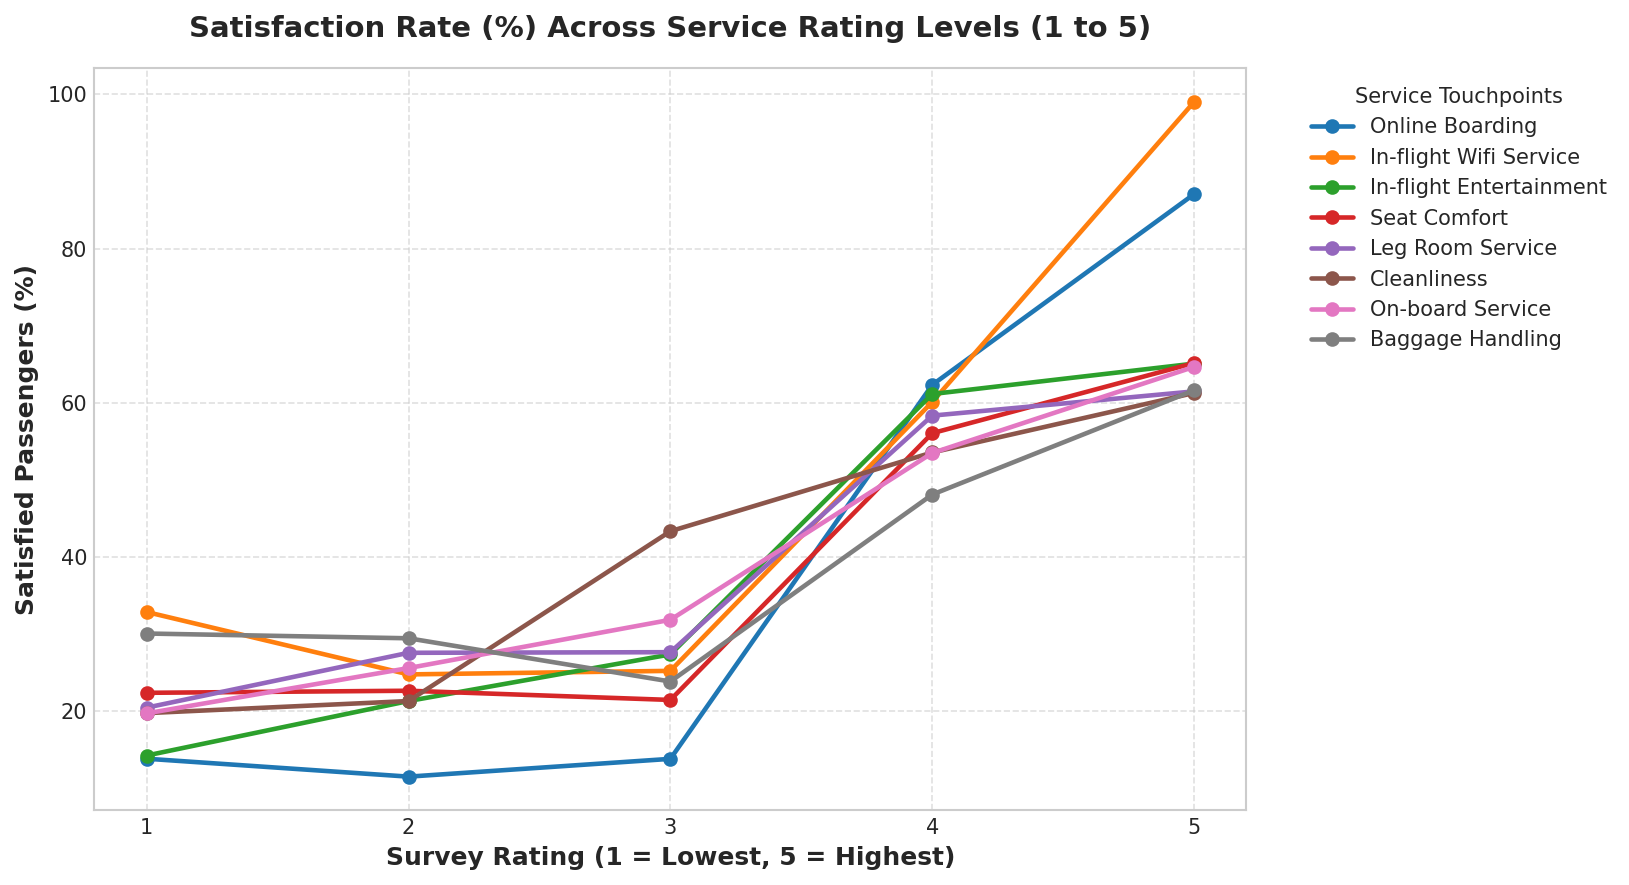

In [10]:
# Visualization 4: Satisfaction Rate Across Service Touchpoint Rating Levels (1-5)
services = [
    "Online Boarding", "In-flight Wifi Service", "In-flight Entertainment",
    "Seat Comfort", "Leg Room Service", "Cleanliness", "On-board Service", "Baggage Handling"
]
df_services = df_raw.copy()
df_services['Sat_Binary'] = (df_services['Satisfaction'] == 'Satisfied').astype(int)

fig, ax = plt.subplots(figsize=(11, 6))
for s in services:
    valid_s = df_services[df_services[s] > 0]
    rate = valid_s.groupby(s)['Sat_Binary'].mean() * 100
    ax.plot(rate.index, rate.values, marker='o', linewidth=2.2, label=s)

ax.set_title("Satisfaction Rate (%) Across Service Rating Levels (1 to 5)", fontsize=14, weight='bold', pad=15)
ax.set_xlabel("Survey Rating (1 = Lowest, 5 = Highest)", fontsize=12, weight='bold')
ax.set_ylabel("Satisfied Passengers (%)", fontsize=12, weight='bold')
ax.set_xticks([1, 2, 3, 4, 5])
ax.legend(title="Service Touchpoints", bbox_to_anchor=(1.04, 1), loc="upper left")
ax.grid(True, linestyle='--', alpha=0.6)
plt.show()


**Empirical Interpretation (Visualization 4):**  
The service rating curves demonstrate steep non-linear threshold dynamics:

- **Online Boarding (Ratings 1 to 5):**
  - Rating 1: **13.78% Satisfied** (86.22% Dissatisfied)
  - Rating 2: **11.45% Satisfied** (88.55% Dissatisfied)
  - Rating 3: **13.76% Satisfied** (86.24% Dissatisfied)
  - Rating 4: **62.30% Satisfied** (37.70% Dissatisfied)
  - Rating 5: **87.06% Satisfied** (12.94% Dissatisfied)

- **In-flight Wifi Service (Ratings 1 to 5):**
  - Rating 1: **32.82% Satisfied** (67.18% Dissatisfied)
  - Rating 2: **24.72% Satisfied** (75.28% Dissatisfied)
  - Rating 3: **25.18% Satisfied** (74.82% Dissatisfied)
  - Rating 4: **60.08% Satisfied** (39.92% Dissatisfied)
  - Rating 5: **99.02% Satisfied** (0.98% Dissatisfied)

*(Note: Rating 0 designates "Not Applicable" per the data dictionary, with 3,906 of 3,916 WiFi-0 passengers being satisfied, primarily business travelers utilizing offline amenities).*


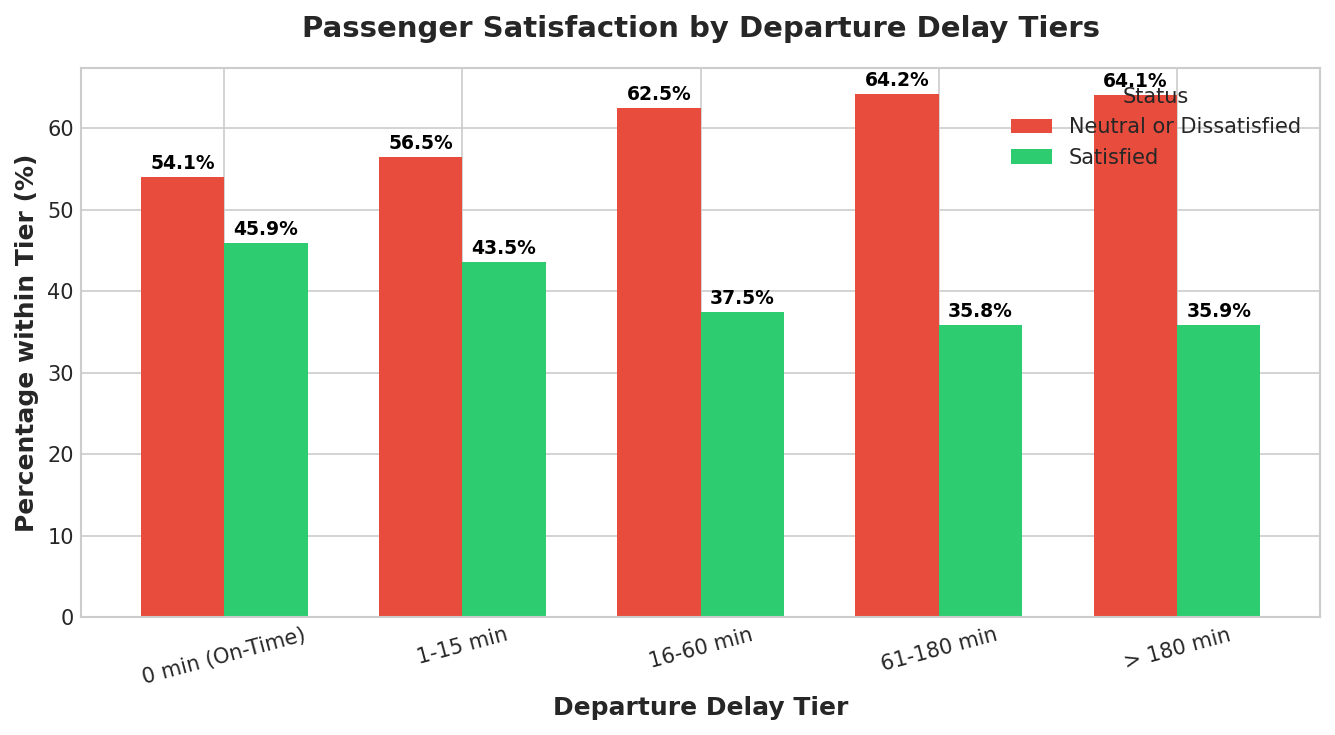

In [11]:
# Visualization 5: Passenger Satisfaction by Departure Delay Tiers
delay_bins = [-1, 0, 15, 60, 180, 2000]
delay_labels = ["0 min (On-Time)", "1-15 min", "16-60 min", "61-180 min", "> 180 min"]
df_delay = df_raw.copy()
df_delay['Dep_Delay_Group'] = pd.cut(df_delay['Departure Delay'], bins=delay_bins, labels=delay_labels)
delay_summary = df_delay.groupby('Dep_Delay_Group', observed=False)['Satisfaction'].value_counts(normalize=True).unstack() * 100

fig, ax = plt.subplots(figsize=(9, 5))
delay_summary[['Neutral or Dissatisfied', 'Satisfied']].plot(
    kind='bar',
    stacked=False,
    color=['#e74c3c', '#2ecc71'],
    ax=ax,
    width=0.7
)
ax.set_title("Passenger Satisfaction by Departure Delay Tiers", fontsize=14, weight='bold', pad=15)
ax.set_xlabel("Departure Delay Tier", fontsize=12, weight='bold')
ax.set_ylabel("Percentage within Tier (%)", fontsize=12, weight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15)
ax.legend(title="Status", loc="upper right")
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"{height:.1f}%",
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=9, color='black', weight='bold',
                    xytext=(0, 2),
                    textcoords='offset points')
plt.show()


**Empirical Interpretation (Visualization 5):**  
Analyzing passenger sentiment across operational departure delay tiers reveals:
- **0 min (On-Time):** **54.06% Dissatisfied**, **45.94% Satisfied**
- **1–15 min delay:** **56.45% Dissatisfied**, **43.55% Satisfied**
- **16–60 min delay:** **62.50% Dissatisfied**, **37.50% Satisfied**
- **61–180 min delay:** **64.15% Dissatisfied**, **35.85% Satisfied**
- **> 180 min delay:** **64.11% Dissatisfied**, **35.89% Satisfied**

*Takeaway:* Dissatisfaction escalates by ~10 percentage points once delays exceed 15 minutes and plateaus around 64% for long delays, proving that while punctuality matters, core touchpoints (boarding, seats, WiFi) account for the majority of baseline dissatisfaction even on on-time flights.


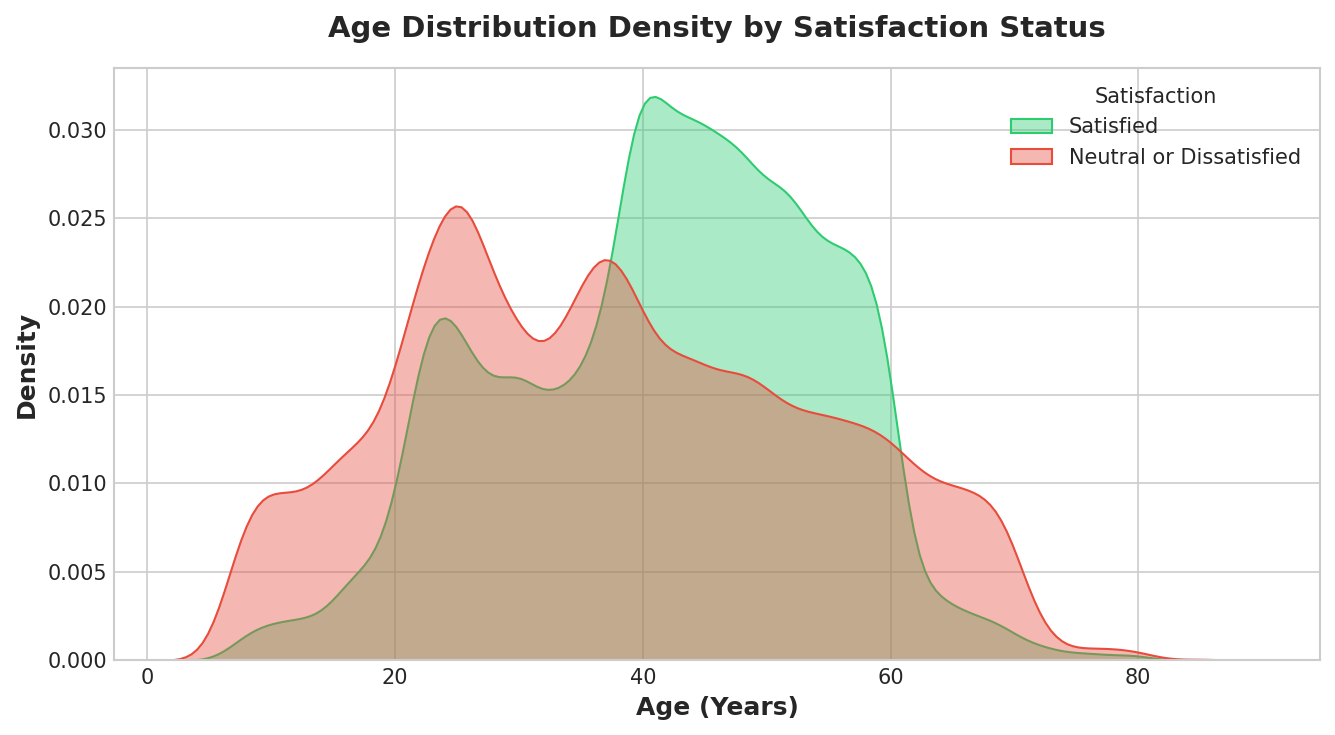

In [12]:
# Visualization 6: Passenger Age Density by Satisfaction Status
fig, ax = plt.subplots(figsize=(9, 5))
sns.kdeplot(data=df_raw[df_raw['Satisfaction'] == 'Satisfied'], x='Age', label='Satisfied', fill=True, color='#2ecc71', alpha=0.4, ax=ax)
sns.kdeplot(data=df_raw[df_raw['Satisfaction'] == 'Neutral or Dissatisfied'], x='Age', label='Neutral or Dissatisfied', fill=True, color='#e74c3c', alpha=0.4, ax=ax)
ax.set_title("Age Distribution Density by Satisfaction Status", fontsize=14, weight='bold', pad=15)
ax.set_xlabel("Age (Years)", fontsize=12, weight='bold')
ax.set_ylabel("Density", fontsize=12, weight='bold')
ax.legend(title="Satisfaction")
plt.show()


**Empirical Interpretation (Visualization 6):**  
Passenger age displays a distinct bimodal dynamic: passengers between ages **40 and 60** show the highest concentration of satisfied passengers (frequent business travelers), whereas young adults (**ages 18 to 32**) are disproportionately dissatisfied.


## 5. Machine Learning Modeling & Diagnostic Evaluation
We train and benchmark two distinct classification architectures within reproducible Scikit-Learn pipelines:
1. **Logistic Regression (Linear Baseline)**: L2 regularized, optimized with L-BFGS.
2. **Random Forest Classifier (Champion Non-Linear Ensemble)**: 100 estimators, max depth of 16, parallelized.


In [13]:
# 1. Train Logistic Regression
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

print("Training Logistic Regression...")
lr_pipeline.fit(X_train, y_train)
lr_preds = lr_pipeline.predict(X_test)
lr_probs = lr_pipeline.predict_proba(X_test)[:, 1]

# 2. Train Random Forest Classifier
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=16, random_state=42, n_jobs=-1))
])

print("Training Random Forest Classifier...")
rf_pipeline.fit(X_train, y_train)
rf_preds = rf_pipeline.predict(X_test)
rf_probs = rf_pipeline.predict_proba(X_test)[:, 1]

print("Model training complete.")


Training Logistic Regression...
Training Random Forest Classifier...
Model training complete.


In [14]:
# Compile and Compare Model Metrics
metrics_summary = [
    {
        'Model': 'Logistic Regression (Baseline)',
        'Accuracy': accuracy_score(y_test, lr_preds),
        'Precision': precision_score(y_test, lr_preds),
        'Recall': recall_score(y_test, lr_preds),
        'F1-Score': f1_score(y_test, lr_preds),
        'ROC-AUC': roc_auc_score(y_test, lr_probs)
    },
    {
        'Model': 'Random Forest (Champion)',
        'Accuracy': accuracy_score(y_test, rf_preds),
        'Precision': precision_score(y_test, rf_preds),
        'Recall': recall_score(y_test, rf_preds),
        'F1-Score': f1_score(y_test, rf_preds),
        'ROC-AUC': roc_auc_score(y_test, rf_probs)
    }
]

metrics_df = pd.DataFrame(metrics_summary)
print(metrics_df.to_string(index=False))


                     Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
Logistic Regression (Baseline)  0.877117   0.871583  0.841149  0.856095  0.929532
      Random Forest (Champion)  0.960887   0.966052  0.942991  0.954382  0.993414


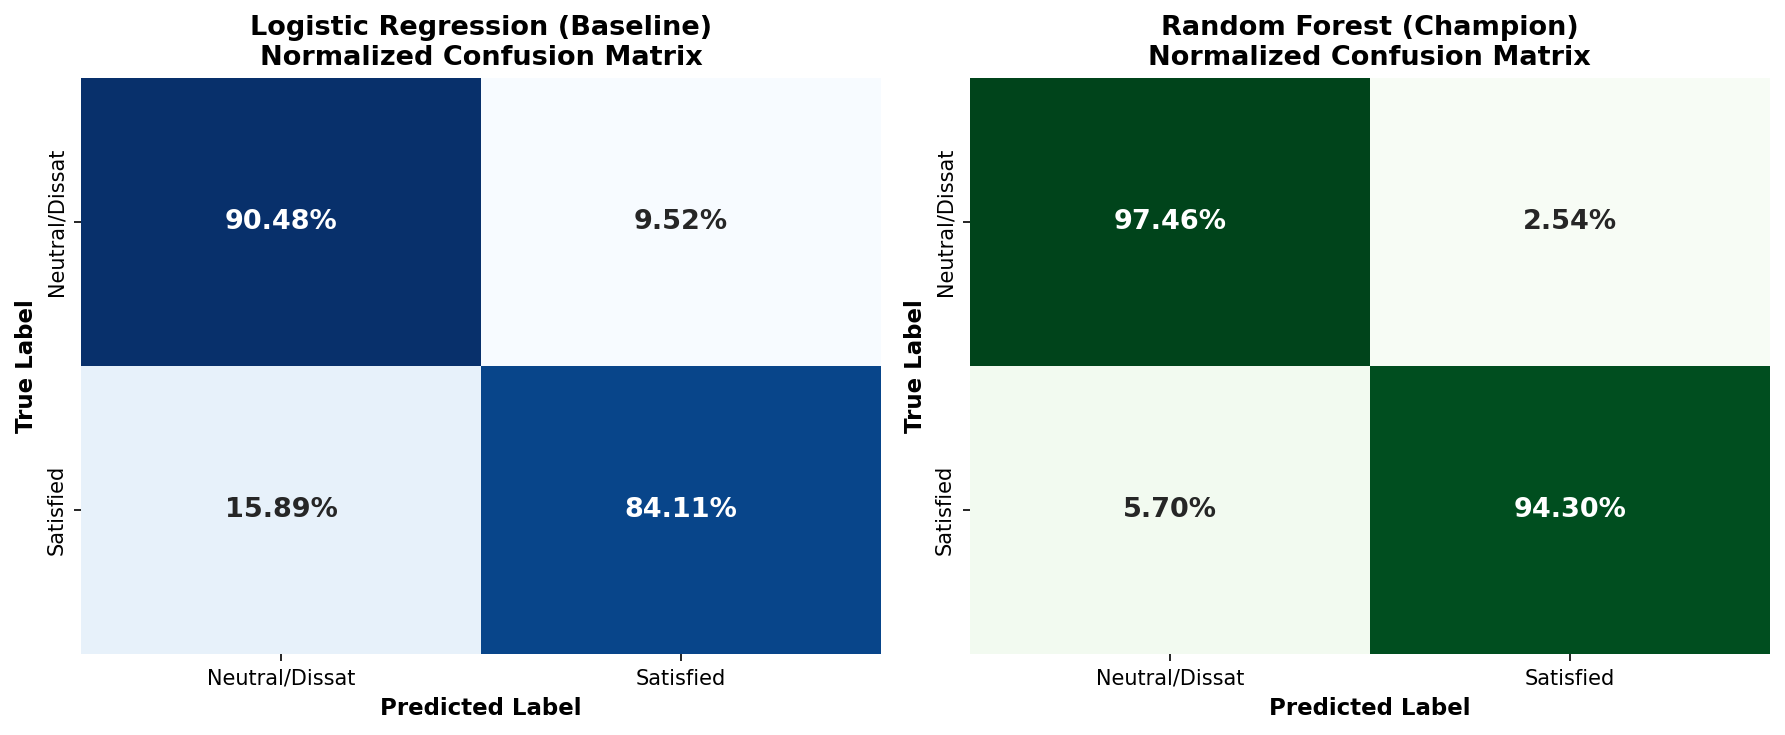

In [15]:
# Visualization 7: Confusion Matrices Comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm_lr = confusion_matrix(y_test, lr_preds, normalize='true')
cm_rf = confusion_matrix(y_test, rf_preds, normalize='true')

sns.heatmap(cm_lr, annot=True, fmt='.2%', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['Neutral/Dissat', 'Satisfied'],
            yticklabels=['Neutral/Dissat', 'Satisfied'], annot_kws={'size': 13, 'weight': 'bold'})
axes[0].set_title("Logistic Regression (Baseline)\nNormalized Confusion Matrix", fontsize=13, weight='bold')
axes[0].set_xlabel("Predicted Label", fontsize=11, weight='bold')
axes[0].set_ylabel("True Label", fontsize=11, weight='bold')

sns.heatmap(cm_rf, annot=True, fmt='.2%', cmap='Greens', ax=axes[1], cbar=False,
            xticklabels=['Neutral/Dissat', 'Satisfied'],
            yticklabels=['Neutral/Dissat', 'Satisfied'], annot_kws={'size': 13, 'weight': 'bold'})
axes[1].set_title("Random Forest (Champion)\nNormalized Confusion Matrix", fontsize=13, weight='bold')
axes[1].set_xlabel("Predicted Label", fontsize=11, weight='bold')
axes[1].set_ylabel("True Label", fontsize=11, weight='bold')

plt.tight_layout()
plt.show()


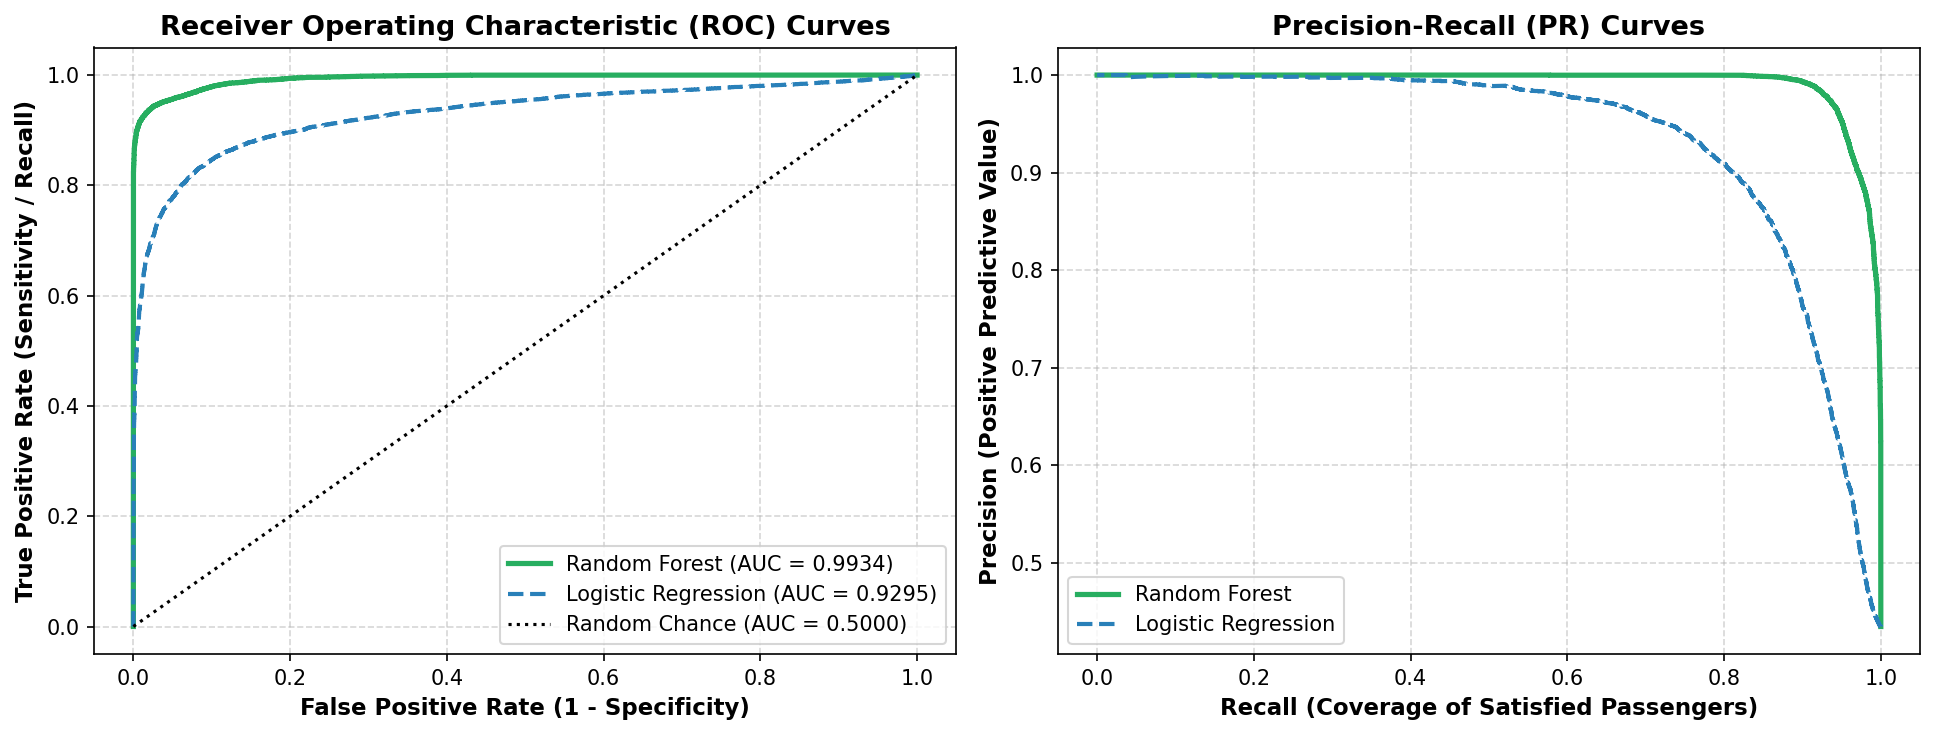

In [16]:
# Visualization 8: ROC and Precision-Recall Curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
auc_lr = roc_auc_score(y_test, lr_probs)
auc_rf = roc_auc_score(y_test, rf_probs)

axes[0].plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.4f})", color='#27ae60', lw=2.5)
axes[0].plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.4f})", color='#2980b9', lw=2, linestyle='--')
axes[0].plot([0, 1], [0, 1], 'k:', label="Random Chance (AUC = 0.5000)")
axes[0].set_title("Receiver Operating Characteristic (ROC) Curves", fontsize=13, weight='bold')
axes[0].set_xlabel("False Positive Rate (1 - Specificity)", fontsize=11, weight='bold')
axes[0].set_ylabel("True Positive Rate (Sensitivity / Recall)", fontsize=11, weight='bold')
axes[0].legend(loc="lower right")
axes[0].grid(True, linestyle='--', alpha=0.5)

prec_lr, rec_lr, _ = precision_recall_curve(y_test, lr_probs)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, rf_probs)

axes[1].plot(rec_rf, prec_rf, label=f"Random Forest", color='#27ae60', lw=2.5)
axes[1].plot(rec_lr, prec_lr, label=f"Logistic Regression", color='#2980b9', lw=2, linestyle='--')
axes[1].set_title("Precision-Recall (PR) Curves", fontsize=13, weight='bold')
axes[1].set_xlabel("Recall (Coverage of Satisfied Passengers)", fontsize=11, weight='bold')
axes[1].set_ylabel("Precision (Positive Predictive Value)", fontsize=11, weight='bold')
axes[1].legend(loc="lower left")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


### Business Evaluation & Error Trade-off Analysis:
- **Random Forest Performance**: Achieves **96.09% accuracy**, **96.61% precision**, **94.30% recall**, and an exceptional **0.9934 ROC-AUC**, capturing non-linear interactions across flight ratings and cabin segments.
- **Cost of False Positives (Type I Error)**: Predicting a passenger is *Satisfied* when they are actually *Dissatisfied*. This is the **most expensive error** in an airline business context because the passenger churns silently without the airline initiating service recovery.
- **Cost of False Negatives (Type II Error)**: Predicting a passenger is *Dissatisfied* when they are actually *Satisfied*. The cost here is low (a minor operational cost for unneeded check-in assistance or courtesy miles).
- *Methodological Disclaimer*: While the model achieves high predictive discrimination, it identifies statistical patterns and correlations rather than proving direct causal mechanics.


## 6. Driver Analysis: Feature Importance Decomposition
We examine the feature importances of the champion Random Forest model to rank the operational levers that most strongly govern satisfaction.


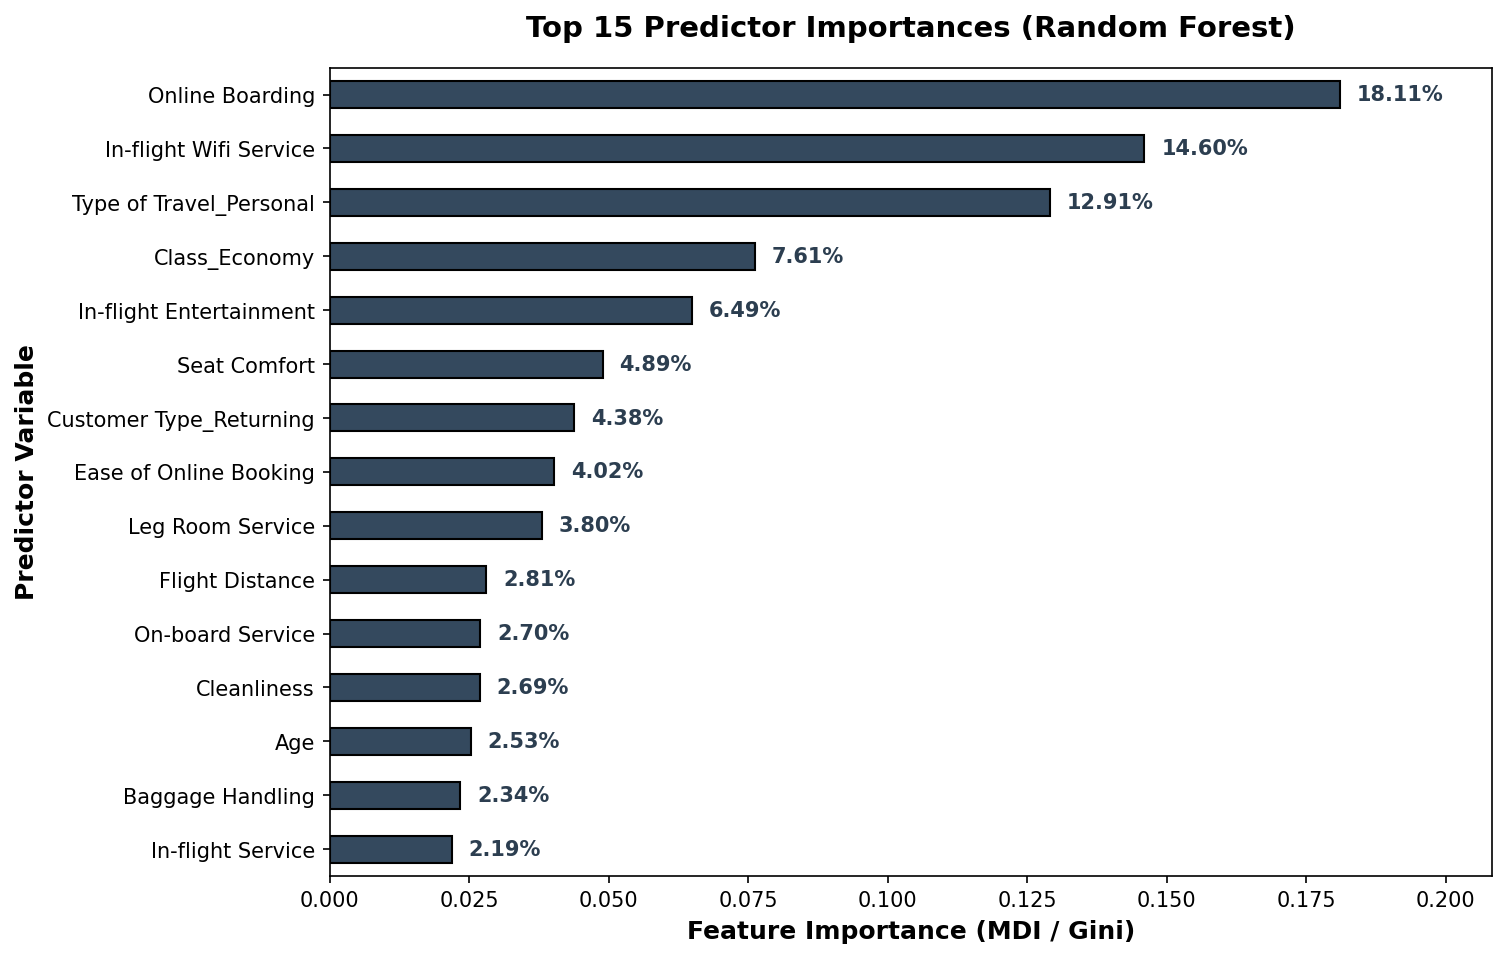

In [17]:
# Extract Feature Importances
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['ohe']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_cols).tolist()
all_feature_names = (continuous_cols + rating_cols) + cat_feature_names

importances = rf_pipeline.named_steps['classifier'].feature_importances_
feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=True)

# Visualization 9: Top 15 Feature Importances
fig, ax = plt.subplots(figsize=(10, 7))
feat_imp.tail(15).plot(kind='barh', color='#34495e', ax=ax, edgecolor='black')
ax.set_title("Top 15 Predictor Importances (Random Forest)", fontsize=14, weight='bold', pad=15)
ax.set_xlabel("Feature Importance (MDI / Gini)", fontsize=12, weight='bold')
ax.set_ylabel("Predictor Variable", fontsize=12, weight='bold')
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.003, p.get_y() + p.get_height()/2, f"{width*100:.2f}%",
            va='center', fontsize=10, weight='bold', color='#2c3e50')
ax.set_xlim(0, max(importances) * 1.15)
plt.show()


### Driver Analysis Insights:
1. **Online Boarding (18.11%)**: The single most dominant touchpoint predictor. Friction during mobile check-in, seat assignment, or boarding gate scanning establishes negative sentiment early in the passenger journey.
2. **In-Flight WiFi Service (14.60%)**: In-flight connectivity is a critical prerequisite. Subpar WiFi ratings severely penalize satisfaction even when physical comfort is acceptable.
3. **Type of Travel - Personal (12.91%) & Class - Economy (7.61%)**: Leisure and Economy travelers face the lowest baseline satisfaction, demanding tailored service interventions.
4. **In-Flight Entertainment (6.49%) & Seat Comfort (4.89%)**: Physical amenities and media availability form the core of in-cabin customer satisfaction.


## 7. Prescriptive Business Insights & Strategic Action Plan

Based strictly on the empirical findings and predictive model outputs, we provide four concrete, high-impact recommendations:

### 1. Digital Gate & Boarding Modernization (Priority 1)
- **Problem**: Online Boarding is the #1 driver of passenger satisfaction (18.1% importance).
- **Action**: Overhaul mobile application boarding flows, implement automated wallet pass generation, and introduce biometric fast-track boarding at hub gates.

### 2. Tiered In-Flight Connectivity Architecture (Priority 2)
- **Problem**: WiFi service is the #2 driver (14.6% importance), with ratings $\le 3$ resulting in $>67-75\%$ dissatisfaction.
- **Action**: Provide free baseline messaging (WhatsApp, iMessage) for all passengers and high-speed streaming packages for loyalty members and business travelers.

### 3. Economy Cabin Comfort Enhancements (Priority 3)
- **Problem**: Economy passengers experience an 81.23% dissatisfaction rate.
- **Action**: Optimize ergonomic seat padding, refresh in-cabin cleanliness between turns, and bundle digital entertainment access with personal devices.

### 4. Automated Real-Time Service Recovery Protocol (Decision Rule)
- **Operational Rule**: 
  - Deploy the Random Forest model at flight check-in and landing.
  - If a passenger exhibits **Predicted Dissatisfaction Risk $> 60\%$** OR experiences **Departure Delay $> 30$ mins** combined with **WiFi/Boarding rating $\le 2$**, automatically trigger an instant mobile compensation voucher (e.g., lounge pass, 1,000 bonus miles, or in-flight meal credit).

---
**Project Delivered by:** Piyush | Principal Data Analyst & Machine Learning Engineer
